# PREDICTING MARKET TRENDS

## OBJECTIVES
Predicting future market trends based on historical data involves using various statistical and machine learning techniques. 


## Pipeline Orchestration

This notebook runs the full end-to-end pipeline:

| Step | Module |
|------|--------|
| 1. Data Ingestion | `ingestion.py` |
| 2. Initial Cleaning | `cleaning.py` → `run_initial_cleaning` |
| 3. EDA + Feature Engineering | `eda.py` → `run_eda` |
| 4. Post-Feature Cleaning | `cleaning.py` → `run_post_feature_cleaning` |
| 5. Model Training & Evaluation | `model.py` → `run_model_pipeline` |

## Step 0 - Data Collection
Data collection was done from Yahoo Finance (yfinance Python Library).It provides historical stock prices, market indices, and company fundamentals.The data available was Open, High, Low, Close, Adjusted Close, Volume. This dataset features the data of S&P 500. 
The S&P 500 is a stock market index comprising 500 leading publicly traded companies in the United States. These companies span various sectors, including technology, healthcare, finance, and consumer goods.

Data Collection Code:


pip install yfinance

import yfinance as yf


ticker = "^GSPC" 

start_date = "2000-01-01"

end_date = "2025-02-10"

(Fetch data from Yahoo Finance)

df = yf.download(ticker, start=start_date, end=end_date)


(Display the first few rows)

print(df.head())


## Step 1 — Data Ingestion

In [1]:
from ingestion import load_data

df = load_data("sp500_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume,policy_change,fedrete
0,1/4/2010,1132.989990,1133.869995,1116.560059,1116.560059,3991400000,0,0.11
1,1/5/2010,1136.520020,1136.630005,1129.660034,1132.660034,2491020000,0,0.11
2,1/6/2010,1137.140015,1139.189941,1133.949951,1135.709961,4972660000,0,0.11
3,1/7/2010,1141.689941,1142.459961,1131.319946,1136.270020,5270680000,0,0.11
4,1/8/2010,1144.979980,1145.390015,1136.219971,1140.520020,4389590000,0,0.11


## Step 2 — Initial Cleaning

Strips column whitespace, drops all-null columns and duplicates, parses dates, and sets Date as the index.

In [2]:
from cleaning import run_initial_cleaning

df = run_initial_cleaning(df)
print("Shape after initial cleaning:", df.shape)

Date              object
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
policy_change      int64
fedrete          float64
dtype: object
Shape after initial cleaning: (4071, 7)


## Step 3 — EDA & Feature Engineering

Runs exploratory summaries, distribution histograms, and correlation heatmap. After feature engineering, generates **boxplots for all numeric columns** to visualise outliers (before they are capped in Step 4). Also plots market trends with moving averages.

In [3]:
from eda import run_eda

df = run_eda(df)
print("Shape after feature engineering:", df.shape)

Shape of the data: (4071, 7)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4071 entries, 2010-01-04 to 2026-03-11
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          4071 non-null   float64
 1   High           4071 non-null   float64
 2   Low            4071 non-null   float64
 3   Open           4071 non-null   float64
 4   Volume         4071 non-null   int64  
 5   policy_change  4071 non-null   int64  
 6   fedrete        4071 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 254.4 KB

Summary Statistics:
              Close         High          Low         Open        Volume  \
count  4071.000000  4071.000000  4071.000000  4071.000000  4.071000e+03   
mean   2990.612210  3005.852905  2972.882395  2989.983483  4.033233e+09   
std    1541.346585  1548.753714  1532.798903  1541.160411  1.006003e+09   
min    1022.580017  1032.949951  1010.909973 

Shape after feature engineering: (4071, 70)


- **Close, High, Low, and Open Prices**: Strongly correlated (**1.00**), indicating they move together in the same direction.  
- **Fed Rate & Prices**: Moderate correlation (**~0.72**), suggesting interest rate changes impact stock prices.  
- **Volume**: Weak correlation with stock prices (**~0.12**), indicating trading volume does not strongly influence price movements.  
- **Fed Rate & Volume**: Very weak correlation (**-0.02**), showing little to no direct relationship.  

This heatmap helps understand how market factors interact, guiding feature selection for prediction models.

This chart, Market Trends with Moving Averages, illustrates the long-term price movement of the S&P 500, highlighting key price points such as Open, Close, High, and Low values. The chart shows a strong upward trend over time, with occasional sharp declines representing market corrections or economic downturns. The close alignment of these price points suggests a relatively stable market, except during volatile periods. Moving averages help smooth out short-term fluctuations, making it easier to identify broader trends and potential turning points in the market. Sharp declines or deviations from these moving averages can indicate significant shifts in market sentiment.

## Step 4 — Post-Feature Cleaning

Fills NaN values, applies log1p skewness correction, caps outliers via IQR, removes highly correlated features (|r| > 0.90), and drops any remaining inf/NaN rows.

In [4]:
from cleaning import run_post_feature_cleaning

df = run_post_feature_cleaning(df)
print("Shape after post-feature cleaning:", df.shape)
print("NaN values remaining:", df.isna().sum().sum())

Applying log1p to skewed columns: ['Volume', 'policy_change', 'fedrete', 'Rolling Std (30-day)', 'Shock Event', 'Rolling Volatility', 'Rolling_Volatility_7', 'Rolling_Volatility_14', 'ATR', 'ATR_14', 'Rolling_Std_Close_Open', 'Volume_MA_7', 'Volume_Rate_of_Change', 'Volume_to_Open_Ratio']


Remaining features after removing highly correlated ones:
['Close', 'Volume', 'policy_change', 'fedrete', 'Rolling Std (30-day)', 'Day_of_Week', 'Day_of_Month', 'Month', 'MA_7_50_diff', 'MA_30_200_diff', 'MA_7_slope', 'Pct Change', 'Price_Change_Open_Close', 'Pct_Change_Open_Close', 'Shock Event', 'Rolling_Volatility_7', 'Rolling_Volatility_14', 'ATR', 'ATR_14', 'Rolling_Mean_Close_Open', 'Price_Momentum_100', 'RSI', 'Volume_MA_7', 'Volume_Rate_of_Change', 'Volume_to_Open_Ratio', 'Price_to_7MA', 'Price_to_30MA', 'Volatility-to-Change', 'Open_Close_Momentum_7', 'Open_Close_Momentum_30']
Shape after post-feature cleaning: (3610, 30)
NaN values remaining: 0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning:

invalid value encountered in subtract

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log1p



## Step 5 — Model Training & Evaluation

Creates the target variable, splits into train/test sets, then applies **StandardScaler** (fitted only on training data to prevent leakage) and **PCA** (retaining 95% variance). Trains Random Forest / XGBoost / SVM classifiers and Random Forest / XGBoost regressors, and prints full evaluation metrics.

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\compat.py:105: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



Preparing targets...
Splitting, scaling, and applying shared PCA...
PCA components retained: 18 (95.461% variance)

=== Training & Evaluating Classifiers ===

Random Forest Classification Evaluation:
  Directional Accuracy: 0.8199 (81.99%)
  Precision (Up):       0.8340
  Recall (Up):          0.8829
  F1 Score:             0.8578
              precision    recall  f1-score   support

           0     0.7937    0.7194    0.7547       278
           1     0.8340    0.8829    0.8578       444

    accuracy                         0.8199       722
   macro avg     0.8138    0.8012    0.8062       722
weighted avg     0.8185    0.8199    0.8181       722



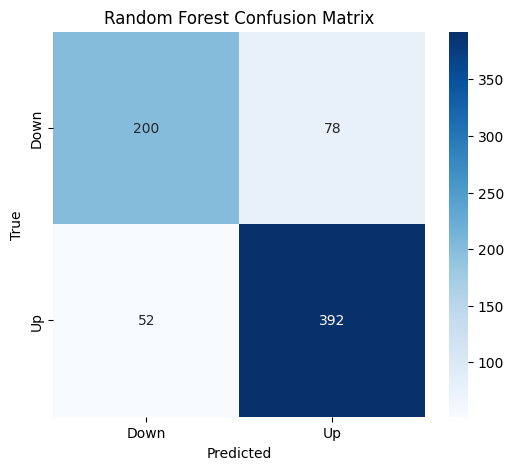


XGBoost Classification Evaluation:
  Directional Accuracy: 0.8061 (80.61%)
  Precision (Up):       0.8290
  Recall (Up):          0.8626
  F1 Score:             0.8455
              precision    recall  f1-score   support

           0     0.7654    0.7158    0.7398       278
           1     0.8290    0.8626    0.8455       444

    accuracy                         0.8061       722
   macro avg     0.7972    0.7892    0.7926       722
weighted avg     0.8045    0.8061    0.8048       722



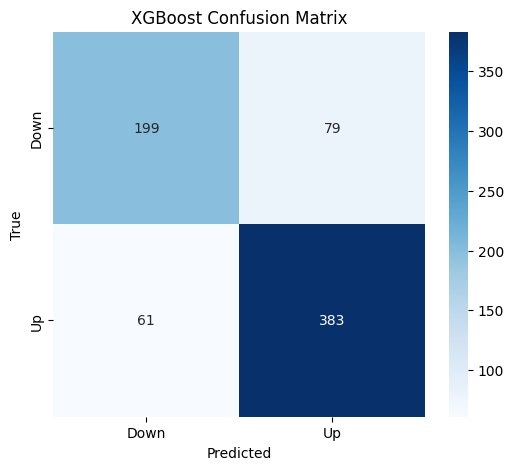


SVM Classification Evaluation:
  Directional Accuracy: 0.8601 (86.01%)
  Precision (Up):       0.8837
  Recall (Up):          0.8896
  F1 Score:             0.8866
              precision    recall  f1-score   support

           0     0.8218    0.8129    0.8174       278
           1     0.8837    0.8896    0.8866       444

    accuracy                         0.8601       722
   macro avg     0.8527    0.8513    0.8520       722
weighted avg     0.8599    0.8601    0.8600       722



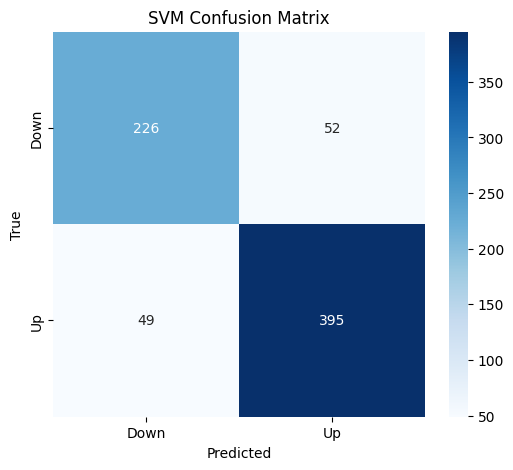


=== Training & Evaluating Regressors ===

Random Forest Regressor Regression Evaluation:
  MSE            : 0.019743
  MAE            : 0.101674
  RMSE           : 0.140511
  R²             : 0.9243
  Directional Acc: 1.0000 (100.00%)

XGBoost Regressor Regression Evaluation:
  MSE            : 0.016256
  MAE            : 0.095817
  RMSE           : 0.127501
  R²             : 0.9377
  Directional Acc: 1.0000 (100.00%)


In [5]:
from model import run_model_pipeline

classifiers, rf_reg, xgb_reg, splits = run_model_pipeline(df)

## Hyperparameter Tuning

Run this cell to perform GridSearchCV-based hyperparameter tuning for regressors and classifiers.

=== Hyperparameter tuning: Regressors (on raw features) ===
Tuning regressors...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best RandomForestRegressor params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV neg MSE: -0.0028158767880630668

Best XGBRegressor params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV neg MSE: -0.0021417353475642565

Tuned RF Regressor (raw features) Regression Evaluation:
  MSE            : 0.001566
  MAE            : 0.017039
  RMSE           : 0.039566
  R²             : 0.9940
  Directional Acc: 1.0000 (100.00%)

Tuned XGBoost Regressor (raw features) Regression Evaluation:
  MSE            : 0.001711
  MAE            : 0.023854
  RMSE           : 0.041368
  R²             : 0.9934
  Directional Acc: 1.0000 (100.00%)
Best tuned regressor selected: RF (tuned) | RMSE=0.039566

=== Hyperparameter tuning: C

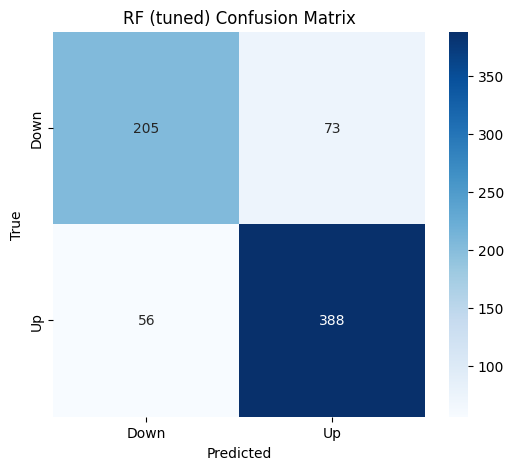


XGBoost (tuned) Classification Evaluation:
  Directional Accuracy: 0.8449 (84.49%)
  Precision (Up):       0.8689
  Recall (Up):          0.8806
  F1 Score:             0.8747
              precision    recall  f1-score   support

           0     0.8051    0.7878    0.7964       278
           1     0.8689    0.8806    0.8747       444

    accuracy                         0.8449       722
   macro avg     0.8370    0.8342    0.8355       722
weighted avg     0.8443    0.8449    0.8445       722



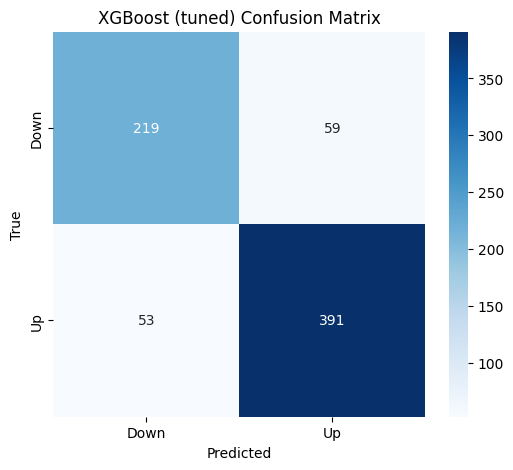


SVM (tuned) Classification Evaluation:
  Directional Accuracy: 0.8601 (86.01%)
  Precision (Up):       0.8837
  Recall (Up):          0.8896
  F1 Score:             0.8866
              precision    recall  f1-score   support

           0     0.8218    0.8129    0.8174       278
           1     0.8837    0.8896    0.8866       444

    accuracy                         0.8601       722
   macro avg     0.8527    0.8513    0.8520       722
weighted avg     0.8599    0.8601    0.8600       722



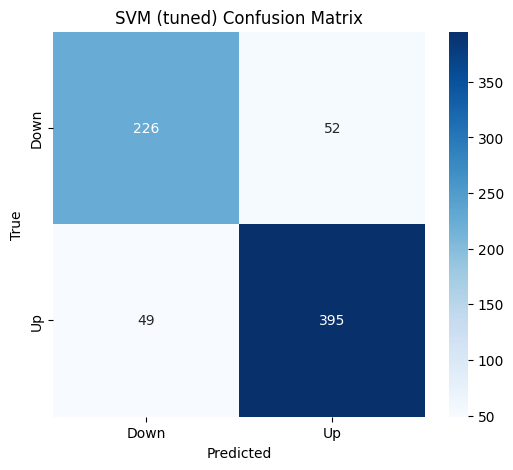

Best tuned classifier selected: SVM (tuned) | F1=0.8866

Selected models for prediction:
  Regressor : RF (tuned)
  Classifier: SVM (tuned)

Quick comparison - default vs tuned classifiers

RF (default) Classification Evaluation:
  Directional Accuracy: 0.8199 (81.99%)
  Precision (Up):       0.8340
  Recall (Up):          0.8829
  F1 Score:             0.8578
              precision    recall  f1-score   support

           0     0.7937    0.7194    0.7547       278
           1     0.8340    0.8829    0.8578       444

    accuracy                         0.8199       722
   macro avg     0.8138    0.8012    0.8062       722
weighted avg     0.8185    0.8199    0.8181       722



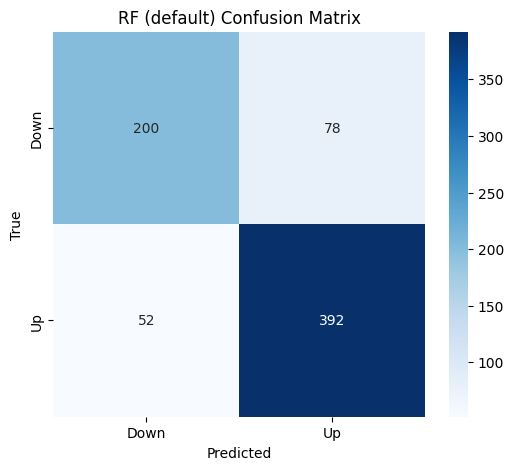


XGBoost (default) Classification Evaluation:
  Directional Accuracy: 0.8061 (80.61%)
  Precision (Up):       0.8290
  Recall (Up):          0.8626
  F1 Score:             0.8455
              precision    recall  f1-score   support

           0     0.7654    0.7158    0.7398       278
           1     0.8290    0.8626    0.8455       444

    accuracy                         0.8061       722
   macro avg     0.7972    0.7892    0.7926       722
weighted avg     0.8045    0.8061    0.8048       722



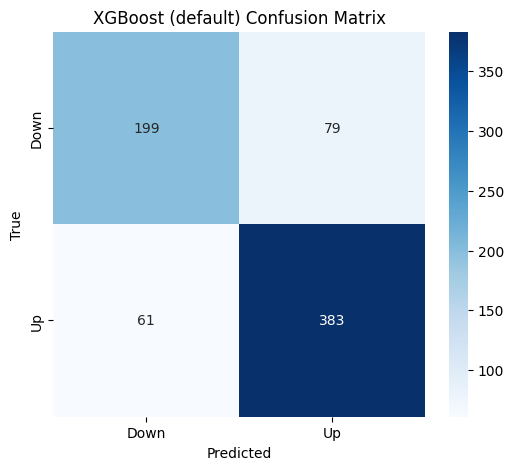


SVM (default) Classification Evaluation:
  Directional Accuracy: 0.8601 (86.01%)
  Precision (Up):       0.8837
  Recall (Up):          0.8896
  F1 Score:             0.8866
              precision    recall  f1-score   support

           0     0.8218    0.8129    0.8174       278
           1     0.8837    0.8896    0.8866       444

    accuracy                         0.8601       722
   macro avg     0.8527    0.8513    0.8520       722
weighted avg     0.8599    0.8601    0.8600       722



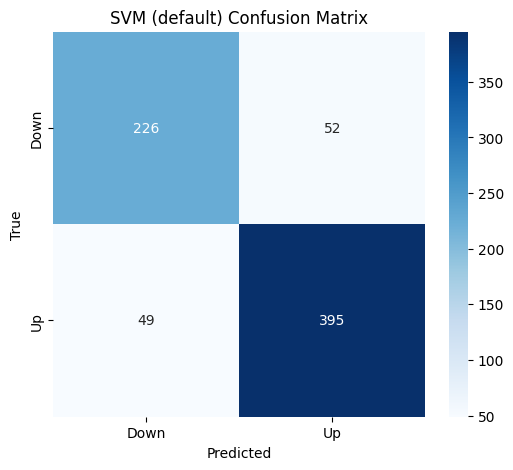

In [6]:
import importlib
import numpy as np
import model
importlib.reload(model)

from sklearn.metrics import mean_squared_error, f1_score
from model import tune_regressors, tune_classifiers, evaluate_regression, evaluate_classifiers

# ────────────────────────────────────────────────
# 1. Tune regressors
# ────────────────────────────────────────────────
print("=== Hyperparameter tuning: Regressors (on raw features) ===")

best_rf_reg, best_xgb_reg = tune_regressors(
    splits["X_train"],
    splits["y_train_reg"]
)

# Evaluate tuned regressors on raw test set
evaluate_regression(best_rf_reg, splits["X_test"], splits["y_test_reg"], "Tuned RF Regressor (raw features)")
evaluate_regression(best_xgb_reg, splits["X_test"], splits["y_test_reg"], "Tuned XGBoost Regressor (raw features)")

# Select best tuned regressor by RMSE 
rf_rmse = np.sqrt(mean_squared_error(splits["y_test_reg"], best_rf_reg.predict(splits["X_test"])))
xgb_rmse = np.sqrt(mean_squared_error(splits["y_test_reg"], best_xgb_reg.predict(splits["X_test"])))
best_reg_model_name = "RF (tuned)" if rf_rmse <= xgb_rmse else "XGBoost (tuned)"
best_reg_model = best_rf_reg if rf_rmse <= xgb_rmse else best_xgb_reg
print(f"Best tuned regressor selected: {best_reg_model_name} | RMSE={min(rf_rmse, xgb_rmse):.6f}")

# ────────────────────────────────────────────────
# 2. Tune classifiers
# ────────────────────────────────────────────────
print("\n=== Hyperparameter tuning: Classifiers (on PCA features) ===")

best_rf_clf, best_xgb_clf, best_svm_clf = tune_classifiers(
    splits["X_train_pca"],
    splits["y_train_clf"]
)

# Collect tuned models for evaluation
tuned_models = {
    "RF (tuned)": best_rf_clf,
    "XGBoost (tuned)": best_xgb_clf,
    "SVM (tuned)": best_svm_clf
}

# Evaluate tuned classifiers
evaluate_classifiers(tuned_models, splits["X_test_pca"], splits["y_test_clf"] )

# Select best tuned classifier by F1 on test split
clf_f1_scores = {name: f1_score(splits["y_test_clf"], mdl.predict(splits["X_test_pca"])) for name, mdl in tuned_models.items()}
best_clf_model_name = max(clf_f1_scores, key=clf_f1_scores.get)
best_clf_model = tuned_models[best_clf_model_name]
print(f"Best tuned classifier selected: {best_clf_model_name} | F1={clf_f1_scores[best_clf_model_name]:.4f}")

# Track selected models + best parameters
selected_models = {
    "regressor_name": best_reg_model_name,
    "regressor": best_reg_model,
    "classifier_name": best_clf_model_name,
    "classifier": best_clf_model
}

best_params = {
    "rf_reg": best_rf_reg.get_params(),
    "xgb_reg": best_xgb_reg.get_params(),
    "rf_clf": best_rf_clf.get_params(),
    "xgb_clf": best_xgb_clf.get_params(),
    "svm_clf": best_svm_clf.get_params(),
    "selected_regressor": selected_models["regressor_name"],
    "selected_classifier": selected_models["classifier_name"]
}

print("\nSelected models for prediction:")
print(f"  Regressor : {selected_models['regressor_name']}")
print(f"  Classifier: {selected_models['classifier_name']}")

print("\nQuick comparison - default vs tuned classifiers")
default_classifiers = {
    "RF (default)": classifiers["Random Forest"],
    "XGBoost (default)": classifiers["XGBoost"],
    "SVM (default)": classifiers["SVM"]
}
evaluate_classifiers(default_classifiers, splits["X_test_pca"], splits["y_test_clf"])

## Predictions

One Day Predicton

In [7]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error, f1_score

# Build selected_models from tuned models if needed
if "selected_models" not in globals():
    required = ["best_rf_reg", "best_xgb_reg", "best_rf_clf", "best_xgb_clf", "best_svm_clf", "splits"]
    if all(name in globals() for name in required):
        rf_rmse = np.sqrt(mean_squared_error(splits["y_test_reg"], best_rf_reg.predict(splits["X_test"])))
        xgb_rmse = np.sqrt(mean_squared_error(splits["y_test_reg"], best_xgb_reg.predict(splits["X_test"])))
        best_reg_model_name = "RF (tuned)" if rf_rmse <= xgb_rmse else "XGBoost (tuned)"
        best_reg_model = best_rf_reg if rf_rmse <= xgb_rmse else best_xgb_reg
        _tuned = {"RF (tuned)": best_rf_clf, "XGBoost (tuned)": best_xgb_clf, "SVM (tuned)": best_svm_clf}
        _f1 = {n: f1_score(splits["y_test_clf"], m.predict(splits["X_test_pca"])) for n, m in _tuned.items()}
        best_clf_name = max(_f1, key=_f1.get)
        selected_models = {
            "regressor_name": best_reg_model_name, "regressor": best_reg_model,
            "classifier_name": best_clf_name,    "classifier": _tuned[best_clf_name]
        }
    else:
        raise RuntimeError("Run the hyperparameter tuning cell first.")

# Ensure the classifier supports predict_proba (SVC needs probability=True at fit time)
best_clf = selected_models["classifier"]
if hasattr(best_clf, 'probability') and not best_clf.probability:
    print(f"Re-fitting {selected_models['classifier_name']} with probability=True...")
    _params = best_clf.get_params()
    _params['probability'] = True
    best_clf = best_clf.__class__(**_params)
    best_clf.fit(splits["X_train_pca"], splits["y_train_clf"])
    selected_models["classifier"] = best_clf
    print("Done.")

# A. Prepare ONE new data point (tomorrow's features)
today_data = {
    'Volume': 4200000000,
    'fedrete': 4.25,
    'Day_of_Week': 1,
    'Day_of_Month': 13,
    'Month': 3,
    'Rolling Std (30-day)': 45.2,
}

new_df = pd.DataFrame([today_data])

# Align to training schema, fill missing with training medians
required_cols = splits["X_train"].columns
train_medians = splits["X_train"].median(numeric_only=True)
new_df = new_df.reindex(columns=required_cols).fillna(train_medians).fillna(0)

# B. Preprocess: scale then PCA
scaler = joblib.load("scaler.pkl")
pca    = joblib.load("pca.pkl")
new_scaled = scaler.transform(new_df)
new_pca    = pca.transform(new_scaled)

# C. Predict with selected best tuned models
best_reg = selected_models["regressor"]
best_clf = selected_models["classifier"]

predicted_close = best_reg.predict(new_df)[0]
up_probability  = best_clf.predict_proba(new_pca)[0][1]
direction       = "Up" if up_probability > 0.5 else "Down"

print(f"Using regressor : {selected_models['regressor_name']}")
print(f"Using classifier: {selected_models['classifier_name']}")
print(f"Predicted next Close price: {predicted_close:,.2f}")
print(f"Predicted direction       : {direction} (confidence: {up_probability:.1%})")

Using regressor : RF (tuned)
Using classifier: SVM (tuned)
Predicted next Close price: 8.33
Predicted direction       : Up (confidence: 100.0%)


Group Prediction

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, f1_score

# Build selected_models if not already in session
if "selected_models" not in globals():
    required = ["best_rf_reg", "best_xgb_reg", "best_rf_clf", "best_xgb_clf", "best_svm_clf", "splits"]
    if all(name in globals() for name in required):
        rf_rmse = np.sqrt(mean_squared_error(splits["y_test_reg"], best_rf_reg.predict(splits["X_test"])))
        xgb_rmse = np.sqrt(mean_squared_error(splits["y_test_reg"], best_xgb_reg.predict(splits["X_test"])))
        best_reg_model_name = "RF (tuned)" if rf_rmse <= xgb_rmse else "XGBoost (tuned)"
        best_reg_model = best_rf_reg if rf_rmse <= xgb_rmse else best_xgb_reg
        _tuned = {"RF (tuned)": best_rf_clf, "XGBoost (tuned)": best_xgb_clf, "SVM (tuned)": best_svm_clf}
        _f1 = {n: f1_score(splits["y_test_clf"], m.predict(splits["X_test_pca"])) for n, m in _tuned.items()}
        best_clf_name = max(_f1, key=_f1.get)
        selected_models = {
            "regressor_name": best_reg_model_name, "regressor": best_reg_model,
            "classifier_name": best_clf_name,    "classifier": _tuned[best_clf_name]
        }
    else:
        raise RuntimeError("Run the hyperparameter tuning cell first.")

# Ensure predict_proba is available on the classifier
best_clf = selected_models["classifier"]
if hasattr(best_clf, 'probability') and not best_clf.probability:
    print(f"Re-fitting {selected_models['classifier_name']} with probability=True...")
    _params = best_clf.get_params()
    _params['probability'] = True
    best_clf = best_clf.__class__(**_params)
    best_clf.fit(splits["X_train_pca"], splits["y_train_clf"])
    selected_models["classifier"] = best_clf
    print("Done.")

# Use test set as demo if no new_data provided
if "new_data" not in globals():
    new_data = splits["X_test"].copy()
    print("new_data not found; using splits['X_test'] as demo input.")

# Align to training schema
required_cols = splits["X_train"].columns
train_medians = splits["X_train"].median(numeric_only=True)
new_data = new_data.reindex(columns=required_cols).fillna(train_medians).fillna(0)

new_scaled = splits["scaler"].transform(new_data)
new_pca    = splits["pca"].transform(new_scaled)

best_reg = selected_models["regressor"]
best_clf = selected_models["classifier"]

reg_preds  = best_reg.predict(new_data)
clf_preds  = best_clf.predict(new_pca)
clf_probas = best_clf.predict_proba(new_pca)[:, 1]

results = pd.DataFrame({
    'Predicted_Close':     reg_preds,
    'Predicted_Direction': np.where(clf_preds == 1, 'Up', 'Down'),
    'Up_Probability':      clf_probas.round(3)
}, index=new_data.index)

print(f"Using regressor : {selected_models['regressor_name']}")
print(f"Using classifier: {selected_models['classifier_name']}")
print(results.tail(10))

new_data not found; using splits['X_test'] as demo input.
Using regressor : RF (tuned)
Using classifier: SVM (tuned)
            Predicted_Close Predicted_Direction  Up_Probability
Date                                                           
2014-12-01         7.611193                Down           0.046
2024-01-23         8.492800                  Up           0.826
2022-05-16         8.302393                Down           0.479
2012-03-01         7.216480                  Up           0.922
2011-12-13         7.113488                Down           0.020
2013-12-12         7.496154                Down           0.129
2024-07-18         8.615923                Down           0.000
2011-09-29         7.067521                  Up           0.973
2025-09-24         8.803372                Down           0.030
2017-01-18         7.730033                  Up           0.573


Real-time / daily prediction function

In [9]:
import pandas as pd
import numpy as np
import joblib

def predict_tomorrow(today_features_df, model_reg=None, model_clf=None):
    """
    Predict next-day Close price and Up/Down direction.
    Uses selected_models (best tuned models) by default.
    today_features_df : dict or 1-row DataFrame
    """
    if model_reg is None:
        model_reg = selected_models["regressor"]
    if model_clf is None:
        model_clf = selected_models["classifier"]

    if not isinstance(today_features_df, pd.DataFrame):
        today_features_df = pd.DataFrame([today_features_df])

    # Align to training schema
    required_cols = splits["X_train"].columns
    train_medians = splits["X_train"].median(numeric_only=True)
    today_features_df = today_features_df.reindex(columns=required_cols).fillna(train_medians).fillna(0)

    scaler = joblib.load("scaler.pkl")
    pca    = joblib.load("pca.pkl")
    scaled      = scaler.transform(today_features_df)
    pca_features = pca.transform(scaled)

    pred_price = model_reg.predict(today_features_df)[0]
    prob_up    = model_clf.predict_proba(pca_features)[0][1]
    direction  = "Up" if prob_up >= 0.5 else "Down"

    return {
        "regressor":       selected_models["regressor_name"],
        "classifier":      selected_models["classifier_name"],
        "predicted_close": round(float(pred_price), 2),
        "direction":       direction,
        "up_probability":  round(float(prob_up) * 100, 1),
        "confidence":      "High" if abs(prob_up - 0.5) > 0.25 else "Medium/Low"
    }


tomorrow_forecast = predict_tomorrow(today_data)

print("Tomorrow's S&P 500 forecast:")
print(f"Regressor used : {tomorrow_forecast['regressor']}")
print(f"Classifier used: {tomorrow_forecast['classifier']}")
print(f"Predicted Close: {tomorrow_forecast['predicted_close']:,.2f}")
print(f"Expected move  : {tomorrow_forecast['direction']}")
print(f"Up probability : {tomorrow_forecast['up_probability']}%")
print(f"Confidence     : {tomorrow_forecast['confidence']}")

Tomorrow's S&P 500 forecast:
Regressor used : RF (tuned)
Classifier used: SVM (tuned)
Predicted Close: 8.33
Expected move  : Up
Up probability : 100.0%
Confidence     : High


## Report Export

Generates a self-contained `report.html` file with model metrics, best hyperparameters, confusion matrix, feature importances, and predictions.

In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
)
from datetime import datetime


def _safe_existing_columns(frame, candidates):
    return [col for col in candidates if col in frame.columns]


_plotly_js_included = False


def _plotly_div(fig):
    global _plotly_js_included
    include_js = 'inline' if not _plotly_js_included else False
    _plotly_js_included = True
    fig.update_layout(
        template='plotly_white',
        paper_bgcolor='white',
        plot_bgcolor='white',
        font=dict(family='Arial, sans-serif', color='#222'),
        margin=dict(l=40, r=20, t=60, b=40)
    )
    return pio.to_html(fig, full_html=False, include_plotlyjs=include_js, config={'responsive': True})


# 1. EDA summary tables
eda_candidate_cols = [
    'Close', 'Open', 'High', 'Low', 'Volume', 'Pct Change',
    '50-day MA', '200-day MA', 'RSI', 'Rolling Volatility'
]
eda_cols = _safe_existing_columns(df, eda_candidate_cols)

missing_df = (
    df.isna()
      .sum()
      .rename('Missing_Count')
      .reset_index()
      .rename(columns={'index': 'Column'})
)
missing_df['Missing_Pct'] = ((missing_df['Missing_Count'] / len(df)) * 100).round(2)
missing_df = missing_df.sort_values(['Missing_Count', 'Column'], ascending=[False, True]).reset_index(drop=True)

summary_df = (
    df[eda_cols].describe().round(4).transpose().reset_index().rename(columns={'index': 'Feature'})
    if eda_cols else pd.DataFrame()
)

dataset_overview = pd.DataFrame([
    {'Metric': 'Rows', 'Value': int(df.shape[0])},
    {'Metric': 'Columns', 'Value': int(df.shape[1])},
    {'Metric': 'Numeric Columns', 'Value': int(df.select_dtypes(include=[np.number]).shape[1])},
    {'Metric': 'Date Range Start', 'Value': str(df.index.min())},
    {'Metric': 'Date Range End', 'Value': str(df.index.max())},
    {'Metric': 'Total Missing Values', 'Value': int(df.isna().sum().sum())}
])

# 2. Interactive Plotly EDA charts
hist_div = '<p>Not available.</p>'

hist_cols = _safe_existing_columns(
    df,
    ['Close', 'Open', 'High', 'Low', 'Volume', 'Pct Change']
)

if hist_cols:

    # Separate volume from other columns
    normal_cols = [c for c in hist_cols if c != 'Volume']
    volume_col = 'Volume' if 'Volume' in hist_cols else None

    figures = []

    # Histogram for normal features
    if normal_cols:
        normal_source = df[normal_cols].copy().reset_index(drop=True)
        normal_source = normal_source.melt(var_name='Feature', value_name='Value')

        normal_fig = px.histogram(
            normal_source,
            x='Value',
            color='Feature',
            facet_col='Feature',
            facet_col_wrap=2,
            nbins=30,
            opacity=0.8,
            color_discrete_sequence=px.colors.qualitative.Bold,
            title='Distributions of Key Numerical Columns'
        )

        normal_fig.for_each_annotation(
            lambda a: a.update(text=a.text.split('=')[-1])
        )

        normal_fig.update_xaxes(matches=None, showticklabels=True)
        normal_fig.update_yaxes(matches=None, showticklabels=True)

        normal_fig.update_layout(
            showlegend=False,
            height=800,
            template="plotly_white"
        )

        figures.append(_plotly_div(normal_fig))

    # Separate histogram for Volume with log scale
    if volume_col:
        volume_fig = px.histogram(
            df,
            x='Volume',
            nbins=40,
            title='Volume Distribution (Log Scale)'
        )

        volume_fig.update_xaxes(type="log")

        volume_fig.update_layout(
            template="plotly_white",
            height=400
        )

        figures.append(_plotly_div(volume_fig))

    # Combine HTML plots
    hist_div = "".join(figures)

corr_div = '<p>Not available.</p>'
corr_cols = _safe_existing_columns(df, ['Close', 'Open', 'High', 'Low', 'Volume', 'Pct Change', 'RSI', 'Rolling Volatility'])
if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr().round(2)
    corr_fig = px.imshow(
        corr_matrix,
        text_auto=True,
        aspect='auto',
        color_continuous_scale='RdBu_r',
        zmin=-1,
        zmax=1,
        title='Correlation Heatmap'
    )
    corr_fig.update_layout(height=600)
    corr_div = _plotly_div(corr_fig)

trend_div = '<p>Not available.</p>'
if 'Close' in df.columns:
    trend_fig = go.Figure()
    trend_fig.add_trace(go.Scatter(
        x=df.index, y=df['Close'], mode='lines', name='Close Price',
        line=dict(color='#1f77b4', width=2)
    ))
    if '50-day MA' in df.columns:
        trend_fig.add_trace(go.Scatter(
            x=df.index, y=df['50-day MA'], mode='lines', name='50-day MA',
            line=dict(color='#ff7f0e', width=2, dash='dash')
        ))
    if '200-day MA' in df.columns:
        trend_fig.add_trace(go.Scatter(
            x=df.index, y=df['200-day MA'], mode='lines', name='200-day MA',
            line=dict(color='#2ca02c', width=2, dash='dot')
        ))
    trend_fig.update_layout(title='Market Trend with Moving Averages', height=500)
    trend_div = _plotly_div(trend_fig)

# 3. Classification metrics
all_clf_models = {**classifiers, **tuned_models}
clf_rows = []
for name, mdl in all_clf_models.items():
    yp = mdl.predict(splits['X_test_pca'])
    clf_rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(splits['y_test_clf'], yp), 4),
        'Precision': round(precision_score(splits['y_test_clf'], yp), 4),
        'Recall': round(recall_score(splits['y_test_clf'], yp), 4),
        'F1': round(f1_score(splits['y_test_clf'], yp), 4)
    })
clf_df = pd.DataFrame(clf_rows).sort_values('F1', ascending=False).reset_index(drop=True)

# 4. Regression metrics
all_reg_models = {
    'RF (default)': (rf_reg, splits['X_test_pca']),
    'XGBoost (default)': (xgb_reg, splits['X_test_pca']),
    'RF (tuned)': (best_rf_reg, splits['X_test']),
    'XGBoost (tuned)': (best_xgb_reg, splits['X_test'])
}
reg_rows = []
for name, (mdl, X_te) in all_reg_models.items():
    yp = mdl.predict(X_te)
    mse = mean_squared_error(splits['y_test_reg'], yp)
    reg_rows.append({
        'Model': name,
        'RMSE': round(np.sqrt(mse), 6),
        'MAE': round(mean_absolute_error(splits['y_test_reg'], yp), 6),
        'R2': round(r2_score(splits['y_test_reg'], yp), 4)
    })
reg_df = pd.DataFrame(reg_rows).sort_values('RMSE').reset_index(drop=True)

# 5. Best hyperparameters
SKIP = {'random_state', 'verbosity', 'n_jobs', 'eval_metric', 'base_score', 'seed'}
hp_rows = []
for key, label in [
    ('rf_reg', 'RF Regressor'),
    ('xgb_reg', 'XGBoost Regressor'),
    ('rf_clf', 'RF Classifier'),
    ('xgb_clf', 'XGBoost Classifier'),
    ('svm_clf', 'SVM Classifier')
]:
    for k, v in best_params.get(key, {}).items():
        if v is not None and k not in SKIP:
            hp_rows.append({'Model': label, 'Parameter': k, 'Value': str(v)})
hp_df = pd.DataFrame(hp_rows)

# 6. Interactive confusion matrix
yp_best = selected_models['classifier'].predict(splits['X_test_pca'])
cm_arr = confusion_matrix(splits['y_test_clf'], yp_best)
cm_fig = px.imshow(
    cm_arr,
    text_auto=True,
    color_continuous_scale='Blues',
    x=['Predicted Down', 'Predicted Up'],
    y=['Actual Down', 'Actual Up'],
    title=f"Confusion Matrix - {selected_models['classifier_name']}"
)
cm_fig.update_layout(height=500)
cm_div = _plotly_div(cm_fig)

# 7. Interactive feature importances
fi_div = '<p>Not available.</p>'
try:
    fi = best_xgb_reg.feature_importances_
    fnames = splits['X_train'].columns
    fi_df = pd.DataFrame({'Feature': fnames, 'Importance': fi}).sort_values('Importance', ascending=False).head(15)
    fi_fig = px.bar(
        fi_df.sort_values('Importance'),
        x='Importance',
        y='Feature',
        orientation='h',
        color='Importance',
        color_continuous_scale='Viridis',
        title='Top 15 Feature Importances - XGBoost Regressor (tuned)'
    )
    fi_fig.update_layout(height=550, coloraxis_showscale=False)
    fi_div = _plotly_div(fi_fig)
except Exception:
    fi_div = '<p>Not available.</p>'

# 8. interactive predictions chart
pred_div = '<p>Not available.</p>'
if 'results' in globals() and not results.empty:
    pred_plot_df = results.tail(50).reset_index().rename(columns={results.index.name or 'index': 'Index'})
    x_col = pred_plot_df.columns[0]
    pred_fig = px.line(
        pred_plot_df,
        x=x_col,
        y='Predicted_Close',
        markers=True,
        color_discrete_sequence=['#636EFA'],
        title='Predicted Close - Last 50 Rows'
    )
    pred_fig.update_layout(height=450)
    pred_div = _plotly_div(pred_fig)

# 9. HTML helpers
def _table(frame, best_col=None, low_best=True, limit=None):
    if frame is None or frame.empty:
        return '<p>Not available.</p>'
    display_df = frame.head(limit) if limit else frame
    html_rows = ''
    best_val = None
    if best_col and best_col in display_df.columns:
        best_val = display_df[best_col].min() if low_best else display_df[best_col].max()
    for _, row in display_df.iterrows():
        highlight = (' style="background:#d4edda;font-weight:bold"'
                     if best_col and row.get(best_col) == best_val else '')
        cells = ''.join(f'<td>{v}</td>' for v in row)
        html_rows += f'<tr{highlight}>{cells}</tr>'
    headers = ''.join(f'<th>{c}</th>' for c in display_df.columns)
    return (
        f'<table class="tbl">'
        f'<thead><tr>{headers}</tr></thead>'
        f'<tbody>{html_rows}</tbody></table>'
    )


def _forecast_rows(fc):
    rows = ''
    for field, val in fc.items():
        if isinstance(val, float):
            val = f'{val:,.4f}'
        rows += f'<tr><td>{field}</td><td>{val}</td></tr>'
    return rows


CSS = """
body{font-family:Arial,sans-serif;background:#f7f9fc;color:#222;margin:0;padding:0}
.wrap{max-width:1200px;margin:40px auto;padding:0 24px}
h1{color:#1a3a5c;border-bottom:3px solid #1a3a5c;padding-bottom:8px}
h2{color:#1a3a5c;margin-top:36px;border-left:5px solid #1a3a5c;padding-left:10px}
.badge{display:inline-block;background:#1a3a5c;color:#fff;border-radius:20px;padding:4px 14px;font-size:.85em;margin:4px 2px}
.tbl{width:100%;border-collapse:collapse;margin:14px 0;font-size:.92em}
.tbl th{background:#1a3a5c;color:#fff;padding:8px 12px;text-align:left}
.tbl td{padding:7px 12px;border-bottom:1px solid #dde;vertical-align:top}
.tbl tr:nth-child(even){background:#eef2fa}
.card{background:#fff;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,.07);padding:22px;margin:20px 0}
.grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(360px,1fr));gap:18px}
.plotly-graph-div{width:100% !important;}
.meta{color:#888;font-size:.86em}
"""

ts = datetime.now().strftime('%Y-%m-%d %H:%M')

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>SP500 ML Report</title>
  <style>{CSS}</style>
</head>
<body><div class="wrap">
  <h1>S&amp;P 500 Market Prediction - ML Pipeline Report</h1>
  <p class="meta">Generated: {ts}</p>

  <div class="card">
    <h2>EDA Overview</h2>
    {_table(dataset_overview)}
  </div>

  <div class="grid">
    <div class="card">
      <h2>Summary Statistics</h2>
      {_table(summary_df)}
    </div>
    <div class="card">
      <h2>Missing Values</h2>
      {_table(missing_df, limit=15)}
    </div>
  </div>

  <div class="card">
    <h2>Interactive Distributions</h2>
    {hist_div}
  </div>

  <div class="grid">
    <div class="card">
      <h2>Interactive Correlation Heatmap</h2>
      {corr_div}
    </div>
    <div class="card">
      <h2>Interactive Market Trend</h2>
      {trend_div}
    </div>
  </div>

  <div class="card">
    <h2>Selected Best Models</h2>
    <span class="badge">Regressor: {selected_models['regressor_name']}</span>
    <span class="badge">Classifier: {selected_models['classifier_name']}</span>
  </div>

  <div class="card">
    <h2>Classification Results</h2>
    {_table(clf_df, best_col='F1', low_best=False)}
  </div>

  <div class="card">
    <h2>Regression Results</h2>
    {_table(reg_df, best_col='RMSE', low_best=True)}
  </div>

  <div class="grid">
    <div class="card">
      <h2>Interactive Confusion Matrix</h2>
      {cm_div}
    </div>
    <div class="card">
      <h2>Interactive Feature Importances</h2>
      {fi_div}
    </div>
  </div>

  <div class="card">
    <h2>Interactive Prediction Trend</h2>
    {pred_div}
  </div>

  <div class="card">
    <h2>Best Hyperparameters</h2>
    {_table(hp_df)}
  </div>

  <div class="card">
    <h2>Batch Predictions (last 20 rows of test set)</h2>
    {results.tail(20).to_html(classes='tbl', border=0)}
  </div>

  <div class="card">
    <h2>Single-Row Forecast</h2>
    <table class="tbl">
      <thead><tr><th>Field</th><th>Value</th></tr></thead>
      <tbody>{_forecast_rows(tomorrow_forecast)}</tbody>
    </table>
  </div>

</div></body></html>"""

out_path = 'report.html'
with open(out_path, 'w', encoding='utf-8') as f:
    f.write(html)
print(f'Report saved -> {out_path}')


Report saved -> report.html


## Save Model for Streamlit App

The following cell saves the trained models and preprocessors so the Streamlit app (`app.py`) can use them for predictions.

In [11]:
import joblib

# Save model bundle for the Streamlit app
model_bundle = {
    "regressor": selected_models["regressor"],
    "classifier": selected_models["classifier"],
    "scaler": splits["scaler"],
    "pca": splits["pca"],
    "regressor_name": selected_models["regressor_name"],
    "classifier_name": selected_models["classifier_name"],
    "feature_columns": list(splits["X_train"].columns),
    "train_medians": splits["X_train"].median(numeric_only=True).to_dict(),
}

joblib.dump(model_bundle, "model_bundle.pkl")
print("✓ Model bundle saved to model_bundle.pkl")
print(f"  - Regressor: {selected_models['regressor_name']}")
print(f"  - Classifier: {selected_models['classifier_name']}")
print(f"  - Feature columns saved: {len(model_bundle['feature_columns'])}")

✓ Model bundle saved to model_bundle.pkl
  - Regressor: RF (tuned)
  - Classifier: SVM (tuned)
  - Feature columns saved: 27


In [12]:
import os

# Verify all required files exist
required_files = {
    "scaler.pkl": "StandardScaler preprocessor",
    "pca.pkl": "PCA transformer",
    "model_bundle.pkl": "Models and metadata"
}

print("=" * 60)
print("VERIFICATION: Checking if Streamlit app can run...")
print("=" * 60)

all_present = True
for filename, description in required_files.items():
    exists = os.path.exists(filename)
    status = "✅ PRESENT" if exists else "❌ MISSING"
    print(f"{status:15} | {filename:20} ({description})")
    all_present = all_present and exists

print("=" * 60)

if all_present:
    print("✅ SUCCESS! All model files saved.")
    print("\nYou can now run:")
    print("  $ streamlit run app.py")
else:
    print("❌ ERROR: Some files are missing!")
    print("Make sure you executed all cells in order before this one.")

print("=" * 60)

VERIFICATION: Checking if Streamlit app can run...
✅ PRESENT       | scaler.pkl           (StandardScaler preprocessor)
✅ PRESENT       | pca.pkl              (PCA transformer)
✅ PRESENT       | model_bundle.pkl     (Models and metadata)
✅ SUCCESS! All model files saved.

You can now run:
  $ streamlit run app.py
